# Clustering

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score, adjusted_rand_score

# from Old.Clustering_and_QC import df_filtered
from src.plotting_functions import *
from src.column_spec import ColumnSpec
from src.clustering import *
from src.filters import *

from src.QC import *
from src.plotting_functions import *
# pio.renderers.default = "png"


In [36]:
# hme1_1      = pd.read_csv("../../Experiment/hme1_1/Data/Processed/20260505_hTERT_HME1_1_processes_phosphoPlus.tsv", sep="\t").fillna(0)
# hme1_2 = pd.read_csv("../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered.tsv", sep="\t", low_memory=False,)
# hek_1       = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260505_HEK293T_raw_selection_processes_phosphoPlus.tsv", sep="\t").fillna(0)
# hme1_mutants = pd.read_csv("../../Experiment/hme1_mutants_test/Data/Processed/20260505_hTERT_HME1_mutants_test_processed_phosphoPlus_filtered.tsv", sep="\t").fillna(0)

# hme1_1 = pd.read_csv("../../Experiment/hme1_1/Data/Processed/20260807_hTERT_HEM1_1_processed_phPlus.tsv", sep="\t", low_memory=False) #.fillna(0)
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv", sep="\t", low_memory=False)
hek_1 = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260807_HEK293T_processed_phPlus.tsv", sep="\t", low_memory=False)


In [37]:
for element in hme1_2.columns:
    print(element)

protein_Id
nrPeptides
description
protein_name
protein_length
nr_tryptic_peptides
peptide_index
peptide_seq
SequenceWindow
Start
End
MaxPepProb
ReferenceIntensity
startModSite
endModSite
NumPhos
LocalizedNumPhos
PhosSites
site
CON
REV
isotopeLabel
WT_raw:abs_EGF_full_r1
WT_raw:abs_EGF_full_r2
WT_raw:abs_EGF_full_r3
WT_raw:abs_EGF_full_r4
WT_raw:abs_EGF_starve_r1
WT_raw:abs_EGF_starve_r2
WT_raw:abs_EGF_starve_r3
WT_raw:abs_EGF_starve_r4
WT_raw:abs_EGF_2_r1
WT_raw:abs_EGF_2_r2
WT_raw:abs_EGF_2_r3
WT_raw:abs_EGF_2_r4
WT_raw:abs_EGF_5_r1
WT_raw:abs_EGF_5_r2
WT_raw:abs_EGF_5_r3
WT_raw:abs_EGF_5_r4
WT_raw:abs_EGF_10_r1
WT_raw:abs_EGF_10_r2
WT_raw:abs_EGF_10_r3
WT_raw:abs_EGF_10_r4
WT_raw:abs_EGF_15_r1
WT_raw:abs_EGF_15_r2
WT_raw:abs_EGF_15_r3
WT_raw:abs_EGF_15_r4
WT_raw:abs_EGF_90_r1
WT_raw:abs_EGF_90_r2
WT_raw:abs_EGF_90_r3
WT_raw:abs_EGF_90_r4
WT_raw:abs_INS_full_r1
WT_raw:abs_INS_full_r2
WT_raw:abs_INS_full_r3
WT_raw:abs_INS_full_r4
WT_raw:abs_INS_starve_r1
WT_raw:abs_INS_starve_r2
WT_raw

## Parameters

Edit the cell below to change the dataset, conditions, and k-scan settings.
All downstream cells read from these variables.

In [38]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the full analysis
# ════════════════════════════════════════════════════════════

df_raw = hek_1                      # dataset to cluster

CELL_LINES   = ["WT"]   # ["WT", "BRAFS151A", "GAB1Y259A"]
CONDITIONS   = ["_EGF_"] #, "_INS_", "_EGFnINS_"]  # ["_EGF_", "_INS_", "_EGFnINS_"]
DATA_TYPE    = "log2:FC"
EXCLUDE_FULL = True

# Filtering
MIN_REPS = 2
MIN_FC   = 0.5                      # |log2FC| threshold (extremes mode)
MAX_FFDR = 0.05                      # limma omnibus F-test FDR cutoff (set to None to skip)

# K-scan
K_RANGE  = range(3, 25, 3)           # k values to test: 5, 10, 15, 20, 25, 30
N_SEEDS  = 5                         # random seeds for stability estimate
MAX_ITER = 200                       # max iterations per run during the scan
N_INIT   = 25                         # number of initializations per k

# Final clustering (set after inspecting the k-scan summary)
K_FINAL     = 12
CLUSTER_COL = f"KMeans_12_cluster_WT_EGF_log2_FC"

# ── Derived — do not edit ────────────────────────────────────────────────────
_scan_cols   = ColumnSpec.select(df_raw, # Extract columns that are going to be used for the custering
                                 cell_lines=CELL_LINES,
                                 data_type=DATA_TYPE,
                                 conditions=CONDITIONS,
                                 exclude_full=EXCLUDE_FULL,
                                 exclude_replicate_cols=True)
N_DIMS       = len(CELL_LINES) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS
print(f"Columns selected: {len(_scan_cols)}  |  Dimensions: {N_DIMS}  |  Timepoints per condition: {N_TIMEPOINTS}")
print(f"Columns to be used for the clustering: {_scan_cols}")

Columns selected: 6  |  Dimensions: 1  |  Timepoints per condition: 6
Columns to be used for the clustering: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']


# Filtering data

In [39]:
df_filtered = filter_by_nreps(df_raw, min_reps=MIN_REPS)
print(f"After n:reps >= {MIN_REPS}:  {df_filtered.shape[0]} sites")

df_filtered = filter_dynamics(df           = df_filtered,
                              cell_lines   = CELL_LINES,
                              conditions   = CONDITIONS,
                              data_type    = "log2:FC",
                              threshold    = MIN_FC,
                              mode         = "extremes",
                              exclude_full = EXCLUDE_FULL,)
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

# ── Responsiveness filter — limma omnibus F-test ─────────────────────────────
# filter_by_ffdr builds "{CellLine}_log2:FFDR_{Condition}_omnibus" (e.g. "WT_log2:FFDR_EGF_omnibus")
# from CELL_LINES x CONDITIONS and keeps the sites limma calls responsive. MAX_FFDR = None skips
# the step, so no `if` is needed around the call.
# combine="any" keeps a site responding in ANY clustered condition. For a joint EGF+INS+EGFnINS
# clustering, conditions=["_ALL_"] is the alternative — one F over all 15 stimulation contrasts
# instead of an OR over three tests.
# Sites limma did not test carry NaN and are dropped — NaN < 0.05 is False.
df_filtered = filter_by_ffdr(df           = df_filtered,
                             cell_lines   = CELL_LINES,
                             conditions   = CONDITIONS,
                             max_ffdr     = MAX_FFDR,
                             combine      = "any",
                             verbose      = True,)
print(f"After FFDR < {MAX_FFDR}:      {df_filtered.shape[0]} sites")

After n:reps >= 2:  23282 sites
After |FC| >= 0.5:      4507 sites
FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 2404 of 4507 sites kept (2103 dropped, of which 0 never tested by limma)
After FFDR < 0.05:      2404 sites


## Filtering LFQ dataset

LFQ dataset requires more fine filtering since peptides without any modifications are also identified. In additino to this, since aququisition is sequential and independent from sample to sample, missingness of peptides in different replicates it is a big problem and has to be taken into account.

In [40]:
# Remove rows without PTM
# df_filtered = df_raw[df_raw.assigned_modifications_clean.notna()]
# print(f"Original size: {df_raw.shape}")
#
# # Drop rows where site is not detected in the starvation control
# df_filtered = df_filtered[df_filtered["WT_raw:abs_EGF_starve_r1"] != 0]
# df_filtered = df_filtered[df_filtered["BRAFS151A_raw:abs_EGF_starve_r1"] != 0]
# df_filtered = df_filtered[df_filtered["GAB1Y259A_raw:abs_EGF_starve_r1"] != 0]
#
# raw_columns = [element for element in df_raw.columns if 'raw' in element]
#
# print(f"Dataframe after removing sites with no starve detected: {df_filtered.shape}")
# replicates = [element for element in raw_columns if "starve" not in element and "cv" not in element and "mean" not in element and "median" not in element and "sd" not in element]
# # print(f"Raw columns of time points replicates: {replicates}")
#
# replicates = list(set([element.replace("_r1", "").replace("_r2", "") for element in replicates]))
#
# suffixes = ["_r1", "_r2"]
#
# # Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
# for condition in replicates:
#     mask = (
#         (df_filtered[f"{condition}{suffixes[0]}"] == 0) &
#         (df_filtered[f"{condition}{suffixes[1]}"] == 0)
#     )
#     df_filtered = df_filtered.drop(df_filtered[mask].index)
#
# print(f"Dataframe after removing sites where a site is missing in the two replivates: {df_filtered.shape}")
#
# df_filtered = filter_dynamics(
#     df           = df_filtered,
#     cell_lines   = CELL_LINES,
#     conditions   = CONDITIONS,
#     data_type    = DATA_TYPE,
#     threshold    = MIN_FC,
#     mode         = "extremes",
#     exclude_full = EXCLUDE_FULL,
# )
# print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

## K-scan — finding the optimal number of clusters

For each k in `K_RANGE` and each random seed the loop collects:
- **Inertia** — total within-cluster DTW distance (seed 0). Lower = tighter. Look for an elbow.
- **Silhouette** — how much closer each site is to its own cluster than to the nearest other (seed 0, precomputed DTW matrix). Range ~0–1; 0.2–0.4 is typical for phosphoproteomics.
- **Stability** — mean pairwise ARI across all seed pairs. Higher = more reproducible at this k.

To use a different algorithm swap `clustering_fn` below:
- `tslearn_clustering_KShape` — drop the `metric` key from `clustering_kwargs`
- `kernnel_clustering` — rename `number_of_clusters` → `n_clusters` and `random_state` → `seed` in the loop call

In [41]:
# # ── Clustering function ─────────────────────────────────────────────────────
# # Swap this line to test a different algorithm (see markdown above).
# clustering_fn = tslearn_clustering_KMeans #clustering functino being used. The reason for this is that if i want to use a different method i only have to change the function here
#
# # Generate a dictionary with all the variables that are going to be used in the clustering algorithms this way you do not have to repeat the same values everywhere
# clustering_kwargs = dict(
#     data_type                = DATA_TYPE,
#     condition_for_clustering = CONDITIONS,
#     cell_lines               = CELL_LINES,
#     exclude_full             = EXCLUDE_FULL,
#     df_dimensions            = N_DIMS,
#     time_series_length       = N_TIMEPOINTS,
#     transpose                = True,
#     max_iterations           = MAX_ITER,
#     n_init                   = N_INIT,
#     metric                   = "euclidean",  # remove this line when using KShape
#     verbose                  = True,
#     testing                  = True,         # must be True to get model + multivariate(np matrix)
# )
#
# # ── Scan loop ────────────────────────────────────────────────────────────────
# inertias, silhouettes, stabilities = [], [], []
#
# for k in K_RANGE:
#     labels_list = []
#
#     for seed in range(N_SEEDS):
#         # _ is the clustered_df
#         # model is parameters of the model used. tslearn model (functions can be applyed to the model)
#         # multivariate is the np matrix reshaped and only carring the time points information
#         _, model, multivariate = clustering_fn(df_to_cluster       = df_filtered.copy(),
#                                                cluster_column_name = f"_kscan_k{k}_s{seed}",
#                                                number_of_clusters  = k,
#                                                random_state        = seed,
#                                                **clustering_kwargs, #arguments pre-defined above
#                                                )
#         labels_list.append(model.labels_) # Extract the labels (clusters) assigned
#
#         if seed == 0:
#             inertias.append(model.inertia_) # inertia (how tight the lcuster is) can be extracted right away from the model
#             D   = cdist_dtw(multivariate) # distances calculated on the np matrix
#             sil = silhouette_score(D, model.labels_, metric="precomputed") # distance of the np matrix to the labels (clusters) -> silhouette
#             silhouettes.append(sil)
#
#     # ARI, checking cluster assignment of all site pairs ?
#     ari_scores = [adjusted_rand_score(labels_list[i], labels_list[j])
#                   for i in range(len(labels_list))
#                   for j in range(i + 1, len(labels_list))]
#     stabilities.append(np.mean(ari_scores))
#     print(f"k={k:3d}  inertia={inertias[-1]:.4f}  silhouette={silhouettes[-1]:.4f}  stability={stabilities[-1]:.4f}")

In [42]:
# # plotting the inertia (better low), silhouette (better high), and stability (better high)
# fig, axes = plot_kscan_summary(K_RANGE, inertias, silhouettes, stabilities)
# plt.show()

### Load k-scan results from the server

The scripts in `scripts/` run the same k-scan in parallel on the calculation server and write a TSV with columns `k`, `inertia`, `silhouette`, `stability` — named `{prefix}_qc_metrics_{conditions}.tsv`.

Point `SERVER_RESULT` at one of those files to plot the full server scan instead of (or alongside) the local one above.

In [43]:
# SERVER_RESULT = "../../Server/Server_results/20260316_calculations/20260316_1650_kernel_kmeans_qc_metrics_EGF.tsv"
#
# server_df = pd.read_csv(SERVER_RESULT, sep="\t")
#
# fig, axes = plot_kscan_summary(
#     ks          = server_df["k"],
#     inertias    = server_df["inertia"],
#     silhouettes = server_df["silhouette"],
#     stabilities = server_df["stability"],
# )
# plt.show()

## Final clustering

Set `K_FINAL` in the Parameters cell after inspecting the k-scan summary, then run this section.

In [44]:
# df_clustered is the results df with the labels of to which cluster each site belongs
# clustering_model is the parameters of the model used. tslearn model (functions can be applyed to the model)
# multivariate is the np matrix reshaped and only carring the time points information
# barycenters are the clusters centroids
df_clustered, clustering_model, multivariate, barycenters = tslearn_clustering_KMeans(
    df_to_cluster            = df_filtered.copy(),
    data_type                = DATA_TYPE, #DATA_TYPE, "log2:FC"
    condition_for_clustering = CONDITIONS,
    cell_lines               = CELL_LINES,
    exclude_full             = EXCLUDE_FULL,
    stoichiometry            = None,
    cluster_column_name      = CLUSTER_COL,
    number_of_clusters       = K_FINAL,
    max_iterations           = 1000,
    n_init                   = 25,
    metric                   = "euclidean",
    df_dimensions            = N_DIMS,
    time_series_length       = N_TIMEPOINTS,
    random_state             = 0,
    transpose                = True,
    verbose                  = True,
    testing                  = True,
    barycenter_calculations  = True,
)
print(f"\nCluster sizes:\n{df_clustered[CLUSTER_COL].value_counts().sort_index()}")

Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_5', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_15', 'WT_log2:FC_EGF_90']

Reshaping dataframe to shape (2404, 6, 1)

The size of the dataset is (2404, 6, 1)
Example:
[[ 0.        ]
 [ 0.24060506]
 [ 0.17642548]
 [ 0.01016878]
 [-0.00824423]
 [-0.60721498]]
Init 1
0.614 --> 0.483 --> 0.469 --> 0.462 --> 0.457 --> 0.453 --> 0.450 --> 0.448 --> 0.445 --> 0.443 --> 0.441 --> 0.440 --> 0.439 --> 0.439 --> 0.438 --> 0.438 --> 0.437 --> 0.437 --> 0.437 --> 0.437 --> 0.437 --> 0.437 --> 0.437 --> 0.437 --> 0.436 --> 0.436 --> 0.436 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 0.435 --> 
Init 2
0.552 --> 0.459 --> 0.446 --> 0.440 --> 0.436 --> 0.434 --> 0.432 --> 0.430 --> 0.428 --> 0.427 --> 0.426 --> 0.425 --> 0.423 --> 0.422 --> 0.421 --> 0.420 --> 0.419 --> 0.418 --> 0.41

In [45]:
fig, ax = plot_sites_umap_interactive(df_clustered,
                                      cell_lines=["WT"], #"WT", "BRAFS151A", "GAB1Y259A"],
                                      conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                      data_type="log2:FC",
                                      exclude_full=True,
                                      color_col=CLUSTER_COL, # None  "protein_name"
                                      hover_cols=None,
                                      n_neighbors=15,
                                      min_dist=0.1,
                                      random_state=42,
                                      figsize=(600, 400),
                                      title=None, )
fig.show()

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Cluster visualization

 Plot not saved


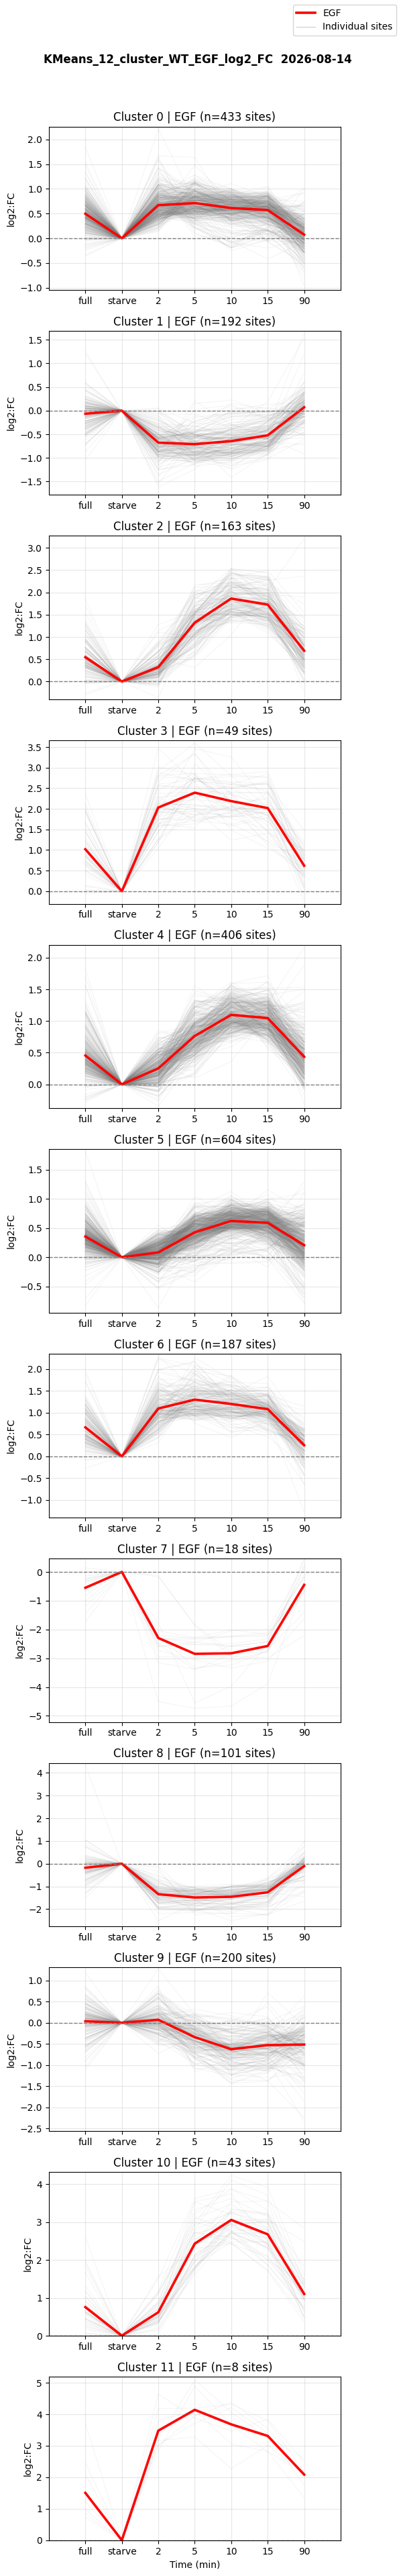

In [46]:
clusters_plot_linear_mutants(
    df                  = df_clustered,
    cluster_column      = CLUSTER_COL,
    data_type           = DATA_TYPE, # DATA_TYPE, "log2:FC"  "log2:scaled" "lod2:zscore"
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    # colors              = {"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"}, # {"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"}
    colors              = {"_EGF_": "red"}, #, "_INS_": "blue", "_EGFnINS_": "fuchsia"},
    panel_by            = "condition", # condition cell_line
    plot_different_data = True,
    legend              = None,
    saving_path         = "",
    saving_info         = "",
    save_pdf            = False,
    save_png            = False,
    plot_close          = False,
    fit_y_lims          = False,
    grey_alpha          = 0.08,
    grey_lw             = 0.8,
    mean_lw             = 2.6,
)

## Substructure diagnostic

Inspect whether any final cluster hides **two shapes**. For a chosen cluster it plots the distance-to-centroid histogram with 1- and 2-component Gaussian fits (a much lower 2-component BIC hints at sub-structure), then compares — per condition — the cluster centroid against the mean of its **close** half vs its **far** half, all in the raw `DATA_TYPE` space the clustering used (no normalization).

`diagnose_cluster_substructure` expects an `AdaptiveClusteringResult`, but `tslearn_clustering_KMeans` returns `clustering_model` / `multivariate` / `barycenters` instead. The cell below wraps those outputs in a light shim exposing exactly the attributes the diagnostic reads (`labels`, `X`, `centroids`, `cluster_sizes`, `params`), so no re-clustering is needed. Reading the diagnostic: treat "2 components preferred" as real sub-structure worth splitting **only** when the close-half vs far-half mean curves also differ in shape — a low 2-component BIC alone often just means a tight core plus a diffuse halo of outliers.

### Why the histogram y-axis is *density*, not *counts*

The left panel is drawn with `density=True`, so matplotlib does **not** plot the number of sites per bin. It rescales every bar so the **total area sums to 1**: `height = count_in_bin / (total_sites × bin_width)`. The y-axis is therefore a **probability density** (probability per unit distance), not a site count. This is deliberate: the overlaid black (1-component) and crimson (2-component) curves come from `np.exp(gmm.score_samples(x))`, which are probability density functions that integrate to 1, so putting the histogram on the same density scale lets bars and GMM curves be compared directly — the whole point of the panel. The absolute count is still shown as `n=…` in the panel title.

Heights above 1 are normal, not a bug: it is the **area** (not the bar heights) that sums to 1, i.e. `Σ(height × bin_width) = 1`. Because height is divided by the bin width, narrow bins give tall bars. Here distances span a small range (~0–2) over 40 bins, so each bin is only ≈ `0.05` wide; a bar of height 2 then holds an area of `2 × 0.05 = 0.10`, i.e. 10 % of the sites. Rule of thumb: when the x-axis spans a range narrower than 1, densities routinely exceed 1; when it spans a wide range, they sit well below 1.

Cluster 0: 433 members
  BIC (1 component): 35.6
  BIC (2 components): -96.7
  Preferred: 2 component(s) (sub-structure likely)


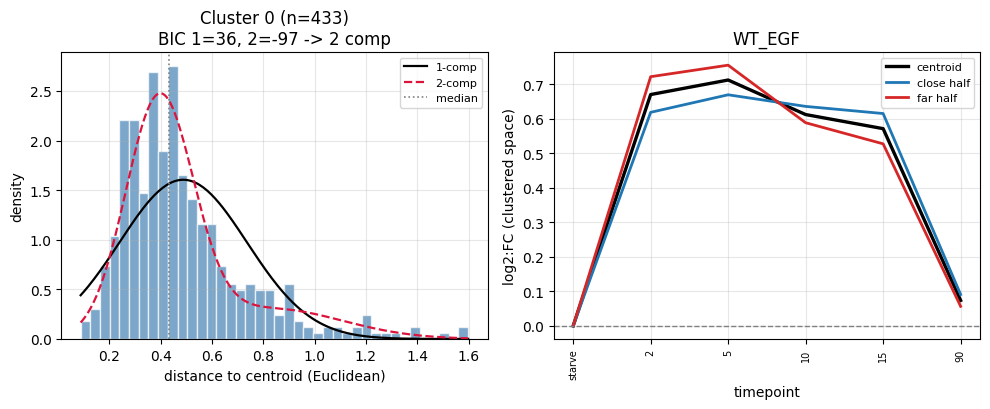

Cluster 0: BIC 1-comp=35.6  2-comp=-96.7  -> preferred 2 component(s)

Cluster 1: 192 members
  BIC (1 component): 84.6
  BIC (2 components): 81.4
  Preferred: 2 component(s) (sub-structure likely)


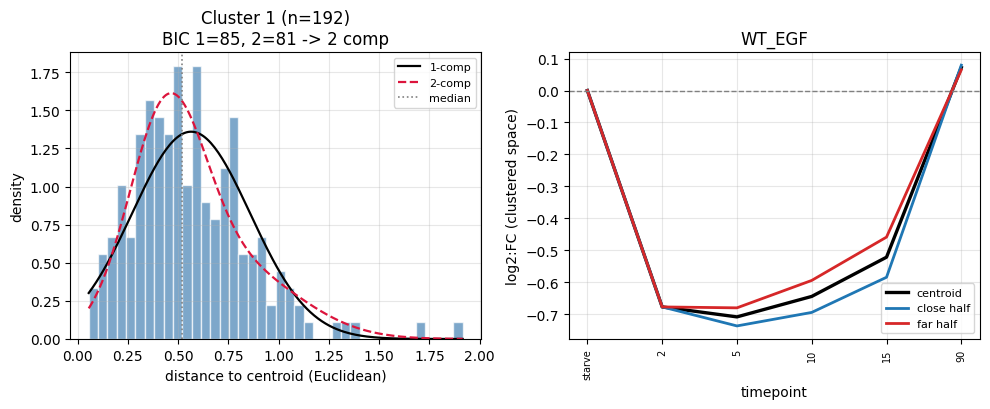

Cluster 1: BIC 1-comp=84.6  2-comp=81.4  -> preferred 2 component(s)

Cluster 2: 163 members
  BIC (1 component): 77.6
  BIC (2 components): 31.5
  Preferred: 2 component(s) (sub-structure likely)


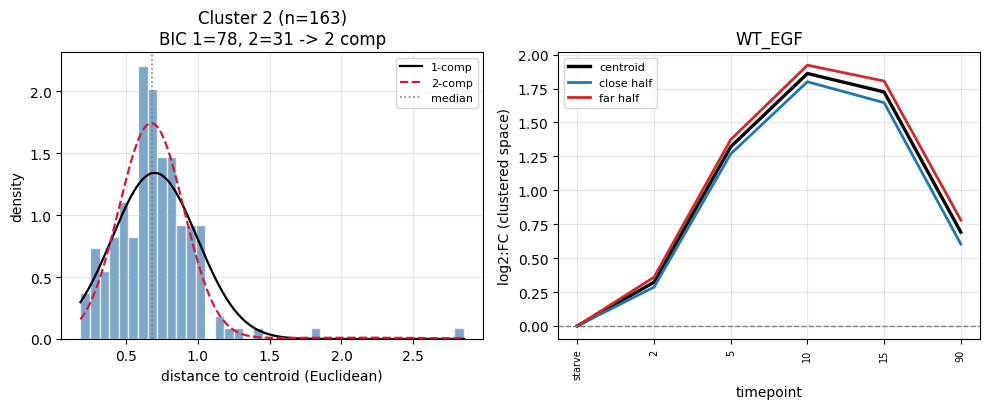

Cluster 2: BIC 1-comp=77.6  2-comp=31.5  -> preferred 2 component(s)

Cluster 3: 49 members
  BIC (1 component): 36.3
  BIC (2 components): 47.6
  Preferred: 1 component(s) (looks unimodal)


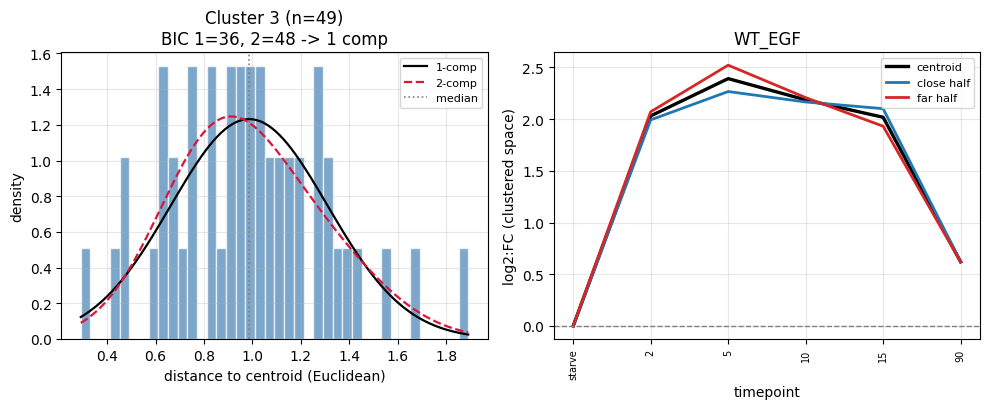

Cluster 3: BIC 1-comp=36.3  2-comp=47.6  -> preferred 1 component(s)

Cluster 4: 406 members
  BIC (1 component): -107.6
  BIC (2 components): -172.4
  Preferred: 2 component(s) (sub-structure likely)


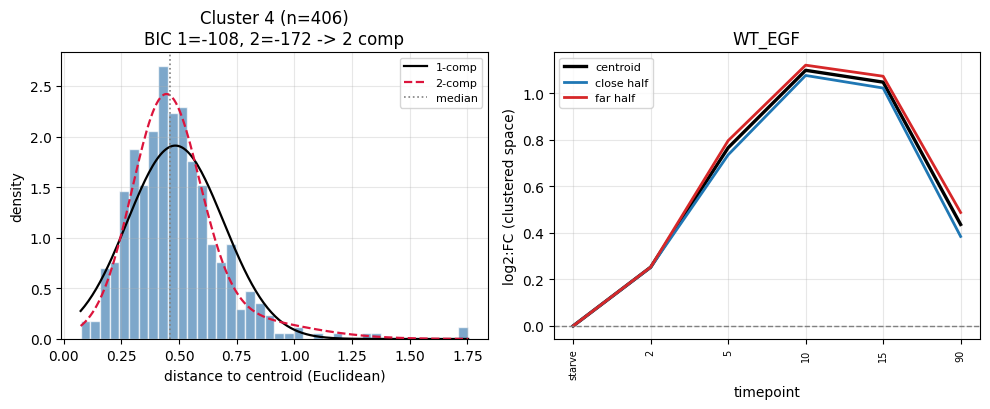

Cluster 4: BIC 1-comp=-107.6  2-comp=-172.4  -> preferred 2 component(s)

Cluster 5: 604 members
  BIC (1 component): -59.5
  BIC (2 components): -290.5
  Preferred: 2 component(s) (sub-structure likely)


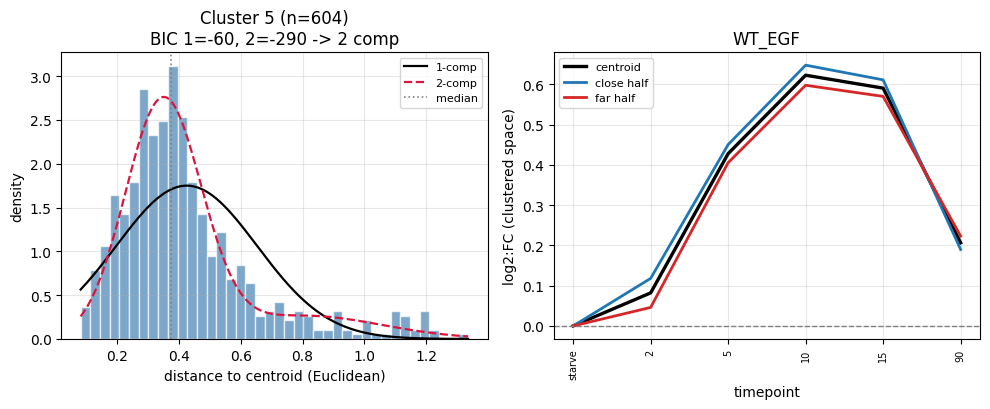

Cluster 5: BIC 1-comp=-59.5  2-comp=-290.5  -> preferred 2 component(s)

Cluster 6: 187 members
  BIC (1 component): 43.0
  BIC (2 components): 22.7
  Preferred: 2 component(s) (sub-structure likely)


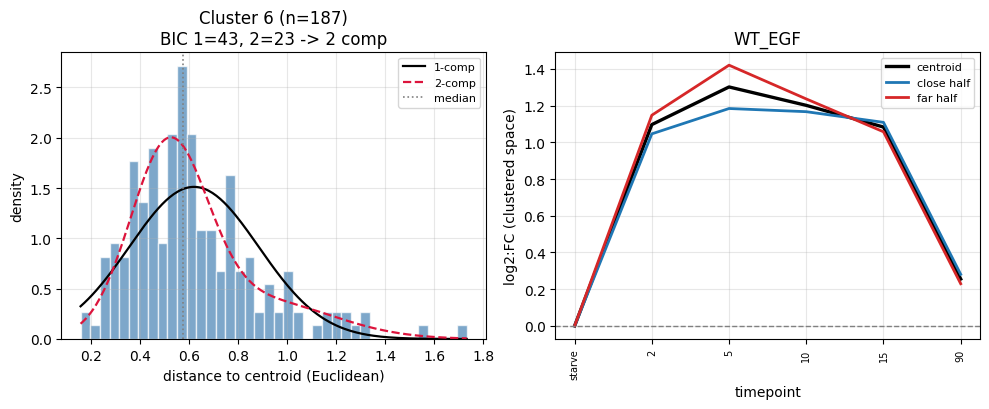

Cluster 6: BIC 1-comp=43.0  2-comp=22.7  -> preferred 2 component(s)

Cluster 7: 18 members
  BIC (1 component): 51.8
  BIC (2 components): 44.4
  Preferred: 2 component(s) (sub-structure likely)


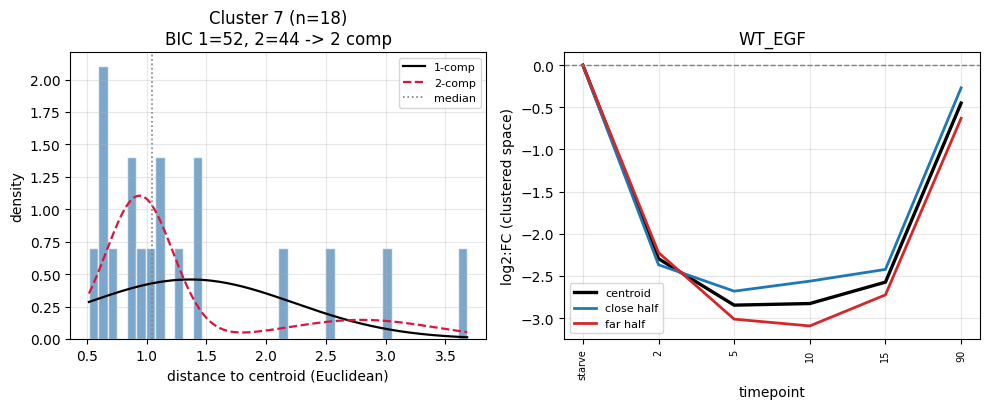

Cluster 7: BIC 1-comp=51.8  2-comp=44.4  -> preferred 2 component(s)

Cluster 8: 101 members
  BIC (1 component): 115.2
  BIC (2 components): 108.7
  Preferred: 2 component(s) (sub-structure likely)


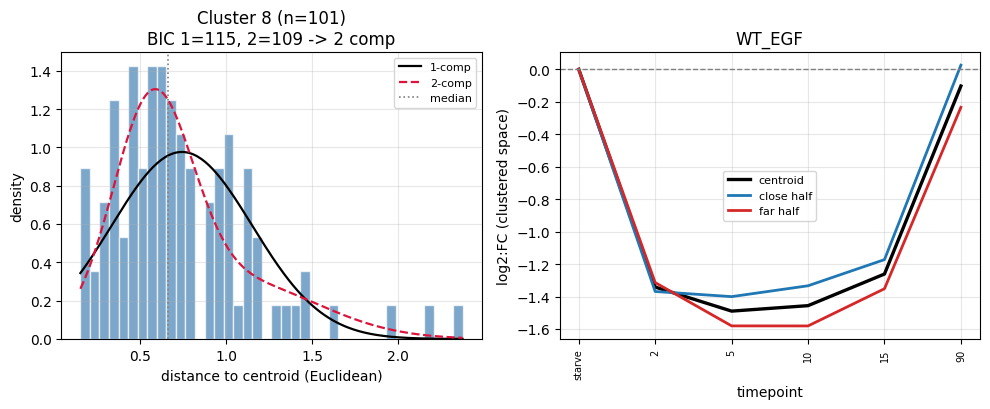

Cluster 8: BIC 1-comp=115.2  2-comp=108.7  -> preferred 2 component(s)

Cluster 9: 200 members
  BIC (1 component): 137.5
  BIC (2 components): 122.7
  Preferred: 2 component(s) (sub-structure likely)


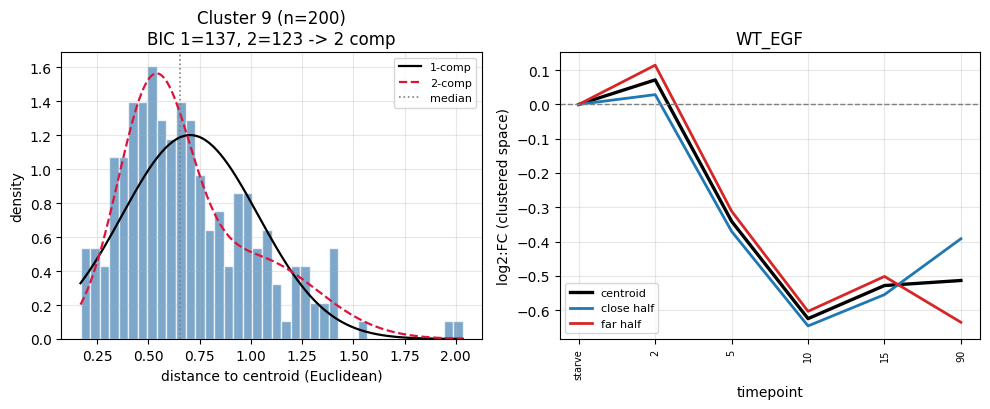

Cluster 9: BIC 1-comp=137.5  2-comp=122.7  -> preferred 2 component(s)

Cluster 10: 43 members
  BIC (1 component): 52.2
  BIC (2 components): 58.6
  Preferred: 1 component(s) (looks unimodal)


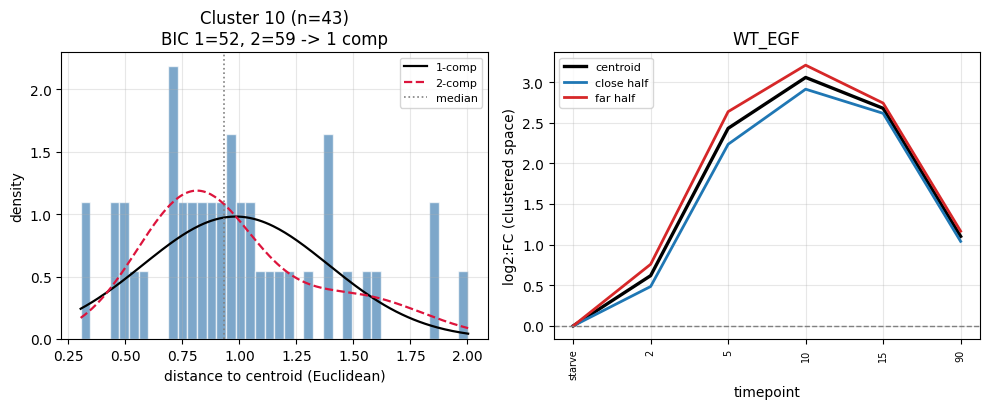

Cluster 10: BIC 1-comp=52.2  2-comp=58.6  -> preferred 1 component(s)

Cluster 11: 8 members
  BIC (1 component): 4.7
  BIC (2 components): -1.5
  Preferred: 2 component(s) (sub-structure likely)


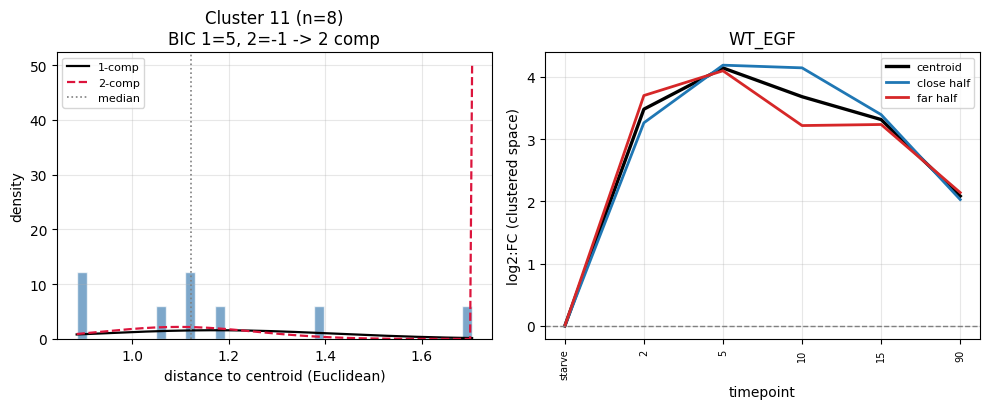

Cluster 11: BIC 1-comp=4.7  2-comp=-1.5  -> preferred 2 component(s)



In [47]:
from types import SimpleNamespace
from src.adaptive_clustering import diagnose_cluster_substructure

# diagnose_cluster_substructure wants an AdaptiveClusteringResult, but tslearn_clustering_KMeans returns (clustering_model, multivariate, barycenters).
# Wrap those in a light shim exposing exactly the attributes the diagnostic reads.
# Reconstruct the same column selection the clustering used, so the diagnostic can map each flattened feature back to its condition/timepoint (via result.params).
_diag_cols = ColumnSpec.select(df_clustered,
                               cell_lines   = CELL_LINES,
                               data_type    = DATA_TYPE,
                               conditions   = CONDITIONS,
                               exclude_full = EXCLUDE_FULL,)

_centroids_flat = clustering_model.cluster_centers_.reshape(clustering_model.cluster_centers_.shape[0], -1,)

diag_result = SimpleNamespace(labels        = clustering_model.labels_,
                              X             = multivariate,
                              centroids     = _centroids_flat,
                              cluster_sizes = df_clustered[CLUSTER_COL].value_counts().sort_index().to_dict(),
                              params        = {"time_series_length": N_TIMEPOINTS,
                                               "column_selection":   _diag_cols,
                                               "transpose":          True,   # matches the final clustering call
                                               "stoichiometry":      None,   # matches the final clustering call
                                               "data_type":          DATA_TYPE,},)

# Inspect every cluster (edit the loop to a single label, e.g. [7], to focus on one).
for lbl in sorted(diag_result.cluster_sizes):
    diag = diagnose_cluster_substructure(diag_result,
                                         cluster_label = lbl,)
    plt.show()
    print(f"Cluster {lbl}: BIC 1-comp={diag['bic_1']:.1f}  2-comp={diag['bic_2']:.1f}  "
          f"-> preferred {diag['preferred_n_components']} component(s)\n")


## Cluster quality — within-cluster Euclidean dispersion

Lower bars mean tighter (more homogeneous) clusters per condition. Distance is measured point-by-point (Euclidean); since all sites share the same fixed timepoints this is appropriate and much faster than DTW.

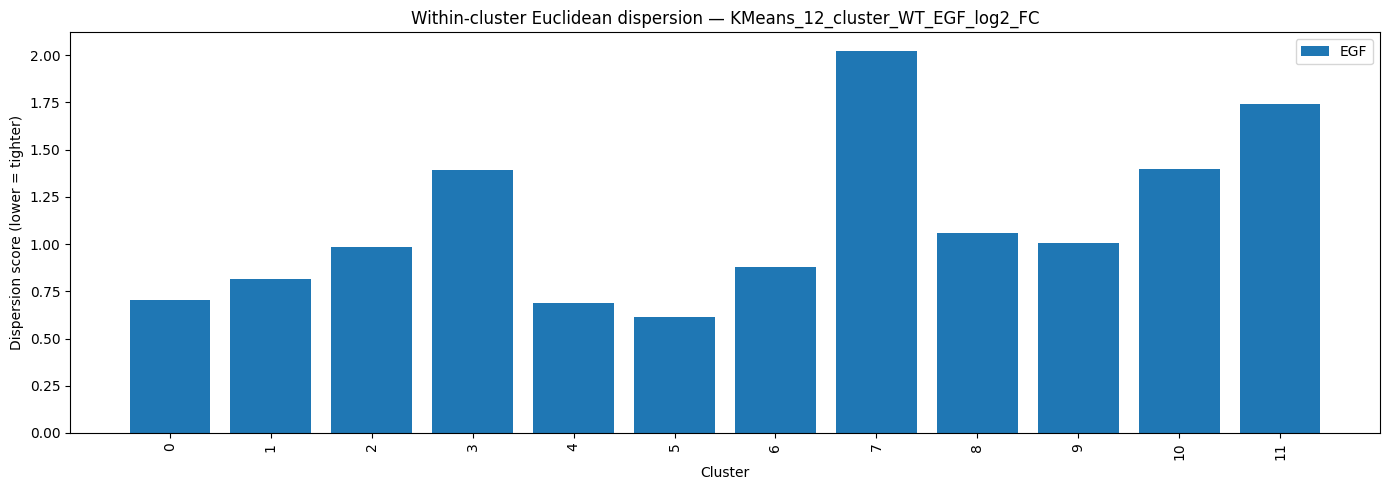

In [48]:
scores = cluster_similarity_per_condition(df                  = df_clustered,
                                          cell_lines          = CELL_LINES,
                                          conditions          = CONDITIONS,
                                          data_type           = DATA_TYPE,
                                          cluster_column_name = CLUSTER_COL,
                                          exclude_full        = EXCLUDE_FULL,
                                          transpose           = True,
                                          # metric              = "DTW",  # euclideanmetric not needed anymore because i am going to use always euclidean, as time series are aligned
                                          )
fig, ax = plot_cluster_scores(scores,
                              cond_order = [c.strip("_") for c in CONDITIONS],
                              title      = f"Within-cluster Euclidean dispersion — {CLUSTER_COL}",)
plt.show()

## Assignment confidence

Four views of how confidently each site was assigned to its cluster:

- **Distance-to-centroid heatmap** — rows are sites (sorted by cluster), columns are clusters; the assigned cluster should be the darkest cell in each row.
- **UMAP** — 2-D embedding of the distance-to-centroid matrix coloured by cluster; tight, well-separated blobs indicate clean assignments.
- **Margin histogram** — margin = (2nd-best distance) − (best distance); higher margin = more confident assignment. The orange line marks the 25th percentile (low-confidence sites).
- **Margin per cluster (boxplot)** — reveals which clusters are internally tight vs. ambiguous.

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


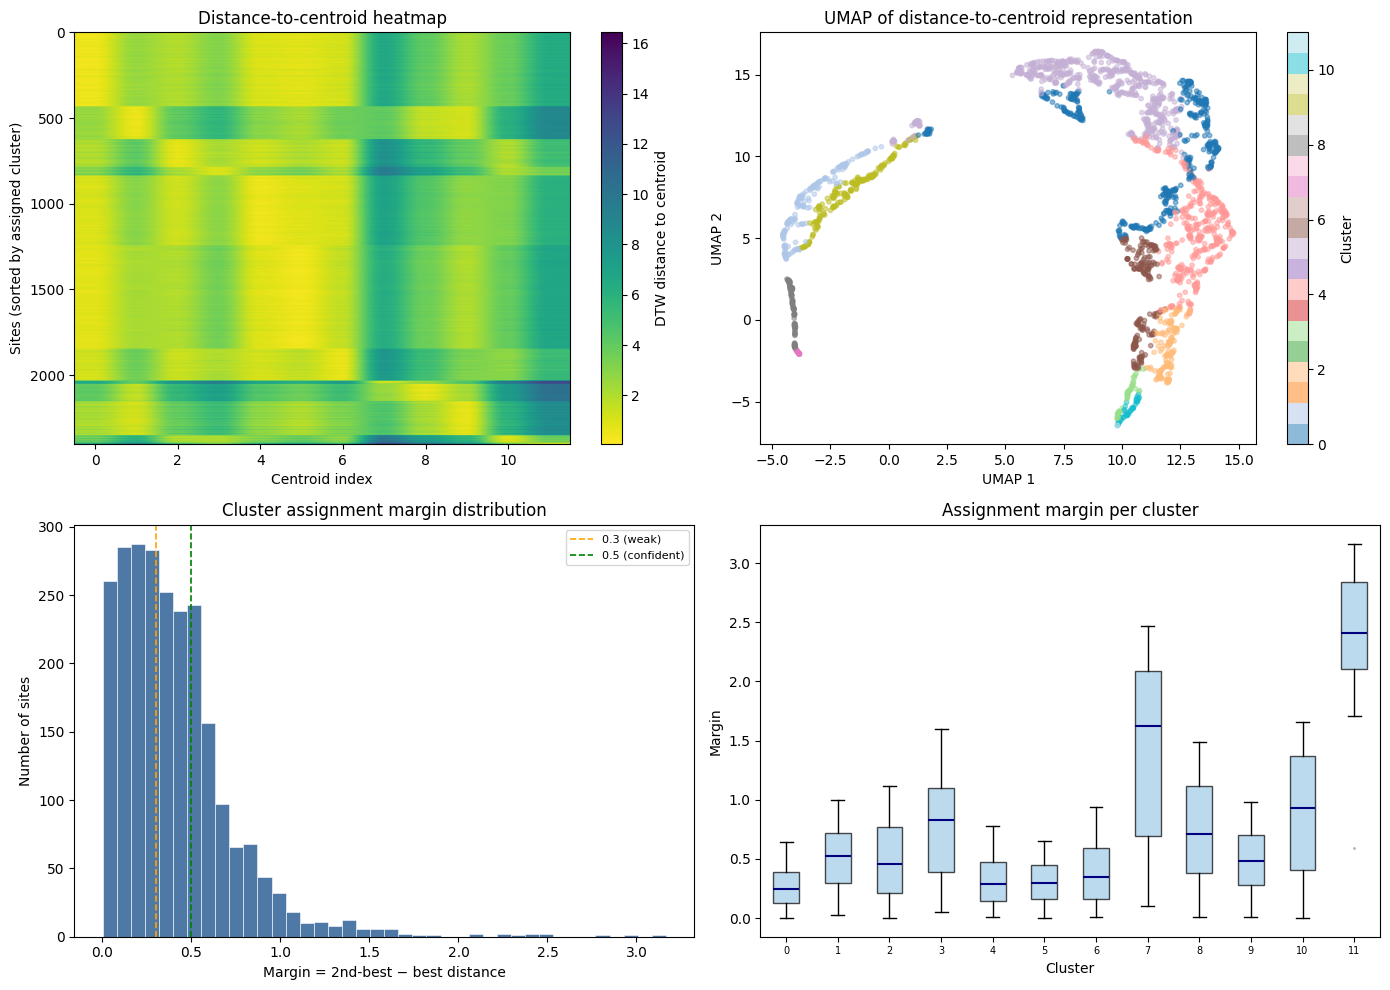

In [49]:
fig, axes = plot_cluster_assignment_qc(barycenters, clustering_model.labels_)
plt.show()

In [50]:
# df_clustered.to_csv("../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered.tsv", sep = "\t", index = False)


## Cluster hierarchy

KMeans assigns sites to clusters but gives them no inherent order. This section imposes structure on the result by taking the **cluster centroids KMeans has already computed** and running hierarchical clustering on those — the sites are never re-clustered, so the tree has only `K_FINAL` leaves and costs nothing to build.

Two outputs:
- **Dendrogram** — which KMeans clusters resemble each other, and at what distance they merge into super-clusters. Use the colour threshold to read off natural groupings.
- **Centroid grid** — the same centroid profiles as the cluster visualisation above, but rows are sorted by dendrogram leaf order so similar clusters appear adjacent. Line colour matches the dendrogram super-cluster colour.

Useful for deciding whether to merge nearby clusters after the k-scan, and for producing a clean ordered summary of the final result.

**Distance is Euclidean, not DTW** (this changed — the previous version used DTW). Two reasons, both from [`clustering_method_decision.md`](clustering_method_decision.md):

1. Every site shares the same fixed timepoints, so the series are already aligned and DTW buys nothing. Worse, DTW *warps time* — and in this experiment the timing of the response is precisely the signal. Two centroids peaking at 2 min and at 15 min are biologically different; DTW is built to call them similar.
2. DTW is not a metric (it violates the triangle inequality), so `ward`, `centroid` and `median` linkage are undefined on a DTW matrix. scipy returns a number anyway, which is worse than an error.

Euclidean on the flattened centroid is also the objective KMeans itself minimised, so the tree and the partition measure the same thing — which is what makes `ward` the natural linkage here.


Centroids: (12, 6, 1)  (clusters, timepoints, conditions)


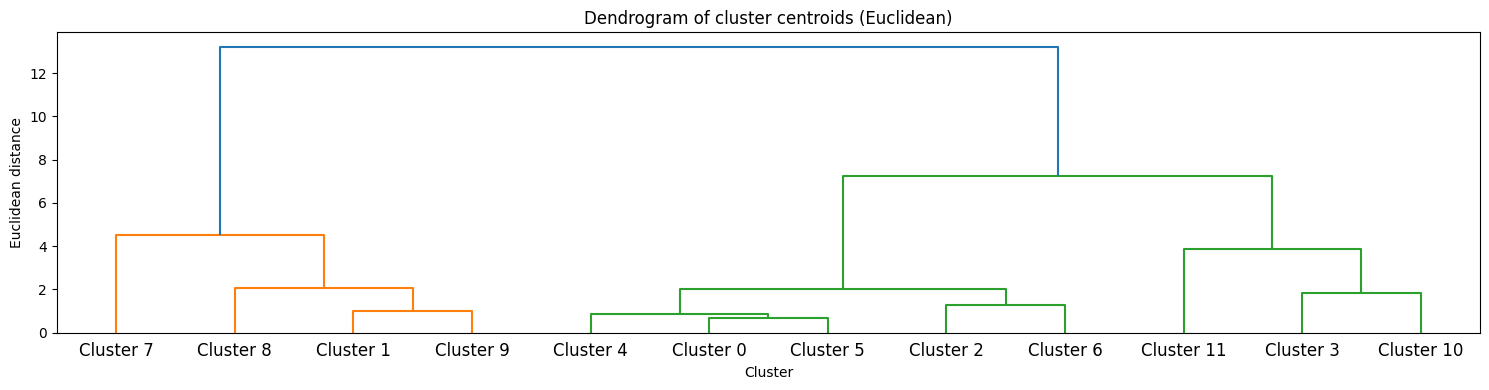

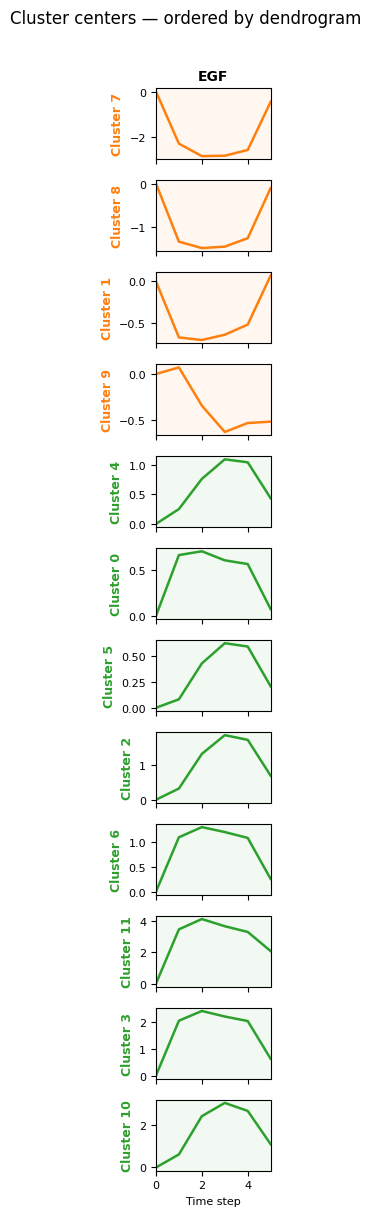


Closest centroid pairs (candidates for merging):
 cluster_a  cluster_b  distance
         0          5  0.666691
         4          5  0.793200
         0          4  0.877592
         1          9  1.018960
         4          6  1.022441


In [51]:
from src.clustering import compute_centroid_linkage

# Hierarchical clustering of the centroids KMeans has ALREADY computed — nothing is
# re-clustered at site level. cluster_centers_ has shape
# (K_FINAL, n_timepoints, n_conditions), so the tree has only K_FINAL leaves and is
# essentially free to build.
print(f"Centroids: {clustering_model.cluster_centers_.shape}  "
      f"(clusters, timepoints, conditions)")

Z_hier, dist_matrix = compute_centroid_linkage(centers = clustering_model.cluster_centers_,
                                               method  = "ward",
                                               metric  = "euclidean",)

fig_dendro, fig_grid = plot_cluster_hierarchy(centers         = clustering_model.cluster_centers_,
                                              Z               = Z_hier,
                                              condition_names = [c.strip("_") for c in CONDITIONS],
                                              color_threshold = 0.7,
                                              metric_label    = "Euclidean",)
plt.show()

# Which centroids sit closest together — the candidates for merging.
_pairs = pd.DataFrame([(i, j, dist_matrix[i, j],)
                       for i in range(dist_matrix.shape[0])
                       for j in range(i + 1, dist_matrix.shape[0])],
                      columns = ["cluster_a", "cluster_b", "distance"],)
print("\nClosest centroid pairs (candidates for merging):")
print(_pairs.sort_values("distance",).head(5,).to_string(index=False,))